<a href="https://colab.research.google.com/github/abinj-ops/Customer_Churn_Prediction/blob/main/Customer_Churn_Prediction_AbinJAntony.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

## Problem Statement
In the highly competitive telecommunications industry, customer retention is a critical factor for long-term profitability. The cost of acquiring a new customer is often significantly higher than retaining an existing one. Therefore, identifying customers who are at a high risk of canceling their service (churning) is a major priority. By anticipating customer churn, the company can proactively intervene with targeted retention strategies, thereby reducing revenue leakage and improving customer satisfaction.

## Objectives
The primary goal of this project is to develop a robust machine learning pipeline to predict customer churn based on historical data.

Specifically, the objectives are to:
1. **Explore and Analyze Data:** Conduct an in-depth Exploratory Data Analysis (EDA) to understand the demographic and behavioral factors that contribute to customer churn.
2. **Engineer Predictive Features:** Transform and create new variables (such as Customer Lifetime Value and Tenure-Contract interactions) to enhance the model's predictive capabilities.
3. **Develop a Predictive Model:** Train, evaluate, and fine-tune various machine learning algorithms (Logistic Regression, Random Forest, Gradient Boosting) to accurately classify whether a customer will churn.
4. **Deliver Actionable Insights:** Extract feature importances to provide data-driven business recommendations for customer retention programs.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
train_df = pd.read_csv("/content/drive/MyDrive/DSA/CaseStudy/Training_data.csv")
test_df = pd.read_csv("/content/drive/MyDrive/DSA/CaseStudy/Testing_data.csv")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (5634, 21)
Testing dataset shape: (1409, 21)


In [4]:
# Display first 5 rows
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [5]:
# Display last 5 rows
train_df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No
5633,3402-XRIUO,NaN,1,Yes,No,22,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,63.55,1381.8,No


In [6]:
# Dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [7]:
# Number of rows and columns
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

Rows: 5634
Columns: 21


In [8]:
# Column names
print(train_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,5634,5634,3402-XRIUO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5465,2,Male,2744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,5634.0,NaN,NaN,NaN,0.159744,0.366401,0.0,0.0,0.0,0.0,1.0
Partner,5634,2,No,2890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,5634,2,No,3960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,5634.0,NaN,NaN,NaN,32.606851,24.614976,0.0,9.0,29.0,56.0,72.0
PhoneService,5634,2,Yes,5081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,5634,3,No,2701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,5634,3,Fiber optic,2486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,5465,3,No,2720,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Number of duplicate rows:", train_df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
train_df = train_df.drop_duplicates()

print("Shape after removing duplicates:", train_df.shape)

Shape after removing duplicates: (5634, 21)


In [12]:
missing_values = train_df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(train_df)) * 100
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
MonthlyCharges,394,6.993255
TotalCharges,281,4.987575
OnlineSecurity,169,2.999645
gender,169,2.999645


In [13]:
for column in train_df.columns:
    print("\n", column)
    print(train_df[column].unique()[:20])


 customerID
['9509-MPYOD' '7746-AWNQW' '2208-UGTGR' '4884-LEVMQ' '6682-VCIXC'
 '7048-GXDAY' '4697-LUPSU' '2432-TFSMK' '2027-WKXMW' '4826-TZEVA'
 '5195-KPUNQ' '6941-KXRRV' '8309-PPCED' '3108-PCCGG' '3214-IYUUQ'
 '2720-FVBQP' '9867-XOBQA' '4282-YMKNA' '4061-UKJWL' '0348-SDKOL']

 gender
['Female' 'Male' nan]

 SeniorCitizen
[0 1]

 Partner
['No' 'Yes']

 Dependents
['No' 'Yes']

 tenure
[35 28 56 39 43  2 18 63 40 53 48 72 61  6 21  9  3 58 57 17]

 PhoneService
['Yes' 'No']

 MultipleLines
['No' 'No phone service' 'Yes']

 InternetService
['No' 'DSL' 'Fiber optic']

 OnlineSecurity
['No internet service' 'No' nan 'Yes']

 OnlineBackup
['No internet service' 'No' 'Yes']

 DeviceProtection
['No internet service' 'Yes' 'No']

 TechSupport
['No internet service' 'Yes' 'No']

 StreamingTV
['No internet service' 'No' 'Yes']

 StreamingMovies
['No internet service' 'No' 'Yes']

 Contract
['One year' 'Month-to-month' 'Two year']

 PaperlessBilling
['No' 'Yes']

 PaymentMethod
['Mailed check' '

In [14]:
if "TotalCharges" in train_df.columns:
    train_df["TotalCharges"] = pd.to_numeric(
        train_df["TotalCharges"],
        errors="coerce"
    )

if "TotalCharges" in test_df.columns:
    test_df["TotalCharges"] = pd.to_numeric(
        test_df["TotalCharges"],
        errors="coerce"
    )

In [15]:
# to fill missing values of gender with mode
train_df["gender"].fillna(train_df["gender"].mode()[0], inplace=True)

/tmp/ipykernel_1396/769605435.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["gender"].fillna(train_df["gender"].mode()[0], inplace=True)


In [16]:
# to fill missing values of monthly charges with median
train_df["MonthlyCharges"].fillna(train_df["MonthlyCharges"].median(), inplace=True)

/tmp/ipykernel_1396/1261529606.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["MonthlyCharges"].fillna(train_df["MonthlyCharges"].median(), inplace=True)


In [17]:
# columns_to_replace = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# train_df[columns_to_replace] = train_df[columns_to_replace].replace('No internet service', 'No')

In [18]:
train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0], inplace=True)

/tmp/ipykernel_1396/3231672505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0], inplace=True)


In [19]:
train_df['TotalCharges'].fillna(train_df['MonthlyCharges'] * train_df['tenure'], inplace=True)

/tmp/ipykernel_1396/3333039141.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['TotalCharges'].fillna(train_df['MonthlyCharges'] * train_df['tenure'], inplace=True)


In [20]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


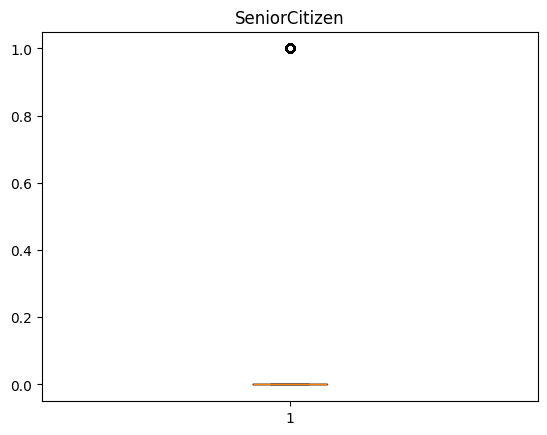

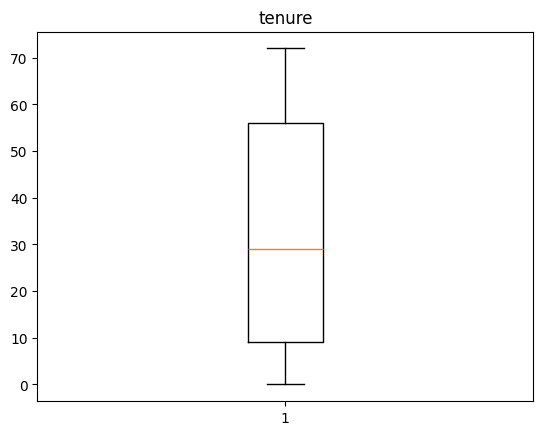

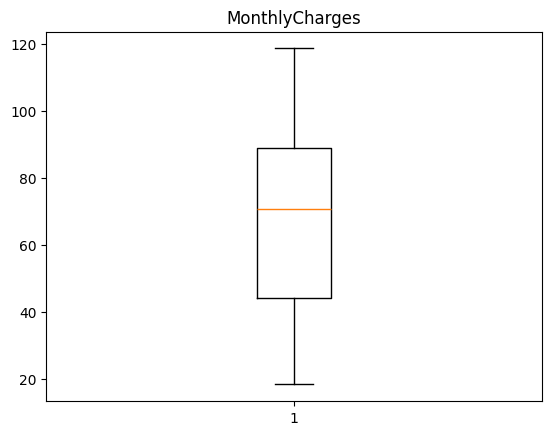

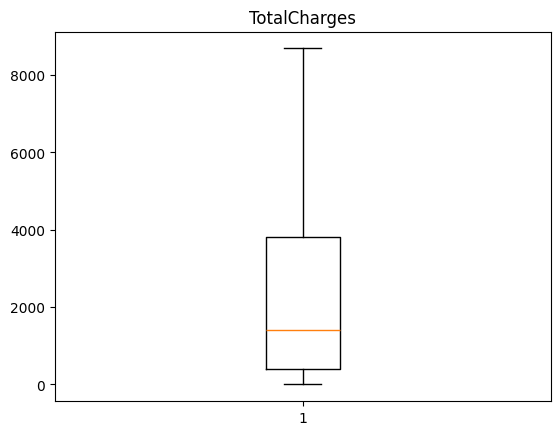

In [21]:
columns = train_df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(train_df[i])
  plt.title(i)
  plt.show()

In [22]:
# manual mapping for all categorical values
gender_mapping = {'Male': 0, 'Female': 1}
train_df['gender'] = train_df['gender'].map(gender_mapping)
train_df['Partner'] = train_df['Partner'].map({'Yes': 1, 'No': 0})
train_df['Dependents'] = train_df['Dependents'].map({'Yes': 1, 'No': 0})
train_df['PhoneService'] = train_df['PhoneService'].map({'Yes': 1, 'No': 0})
train_df['PaperlessBilling'] = train_df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})
train_df['MultipleLines'] = train_df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 2})
train_df['InternetService'] = train_df['InternetService'].map({'Fiber optic': 0, 'DSL': 1, 'No': 2})
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['OnlineBackup'] = train_df['OnlineBackup'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['DeviceProtection'] = train_df['DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['TechSupport'] = train_df['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['StreamingTV'] = train_df['StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['StreamingMovies'] = train_df['StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service': 2})
train_df['Contract'] = train_df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
train_df['PaymentMethod'] = train_df['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3})

In [23]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,1,0,0,0,35,1,0,2,2,...,2,2,2,2,1,0,1,20.75,700.45,0
1,7746-AWNQW,1,0,0,0,28,0,2,1,0,...,1,1,0,0,0,1,1,35.75,961.40,0
2,2208-UGTGR,0,0,0,0,56,1,1,0,0,...,0,0,1,1,0,0,0,98.60,5581.05,0
3,4884-LEVMQ,0,0,1,0,39,1,0,2,2,...,2,2,2,2,2,1,2,20.45,790.00,0
4,6682-VCIXC,1,0,1,1,43,0,2,1,0,...,0,1,1,0,1,1,2,51.25,2151.60,0


In [24]:
# create interaction features (e.g., combining Tenure and Contract
train_df['Tenure_Contract'] = train_df['tenure'] * train_df['Contract']

In [25]:
# create a feature that captures customer lifetime value (e.g., Tenure * MonthlyCharges
train_df['CustomerLifetimeValue'] = train_df['tenure'] * train_df['MonthlyCharges']

In [26]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Contract,CustomerLifetimeValue
0,9509-MPYOD,1,0,0,0,35,1,0,2,2,...,2,2,1,0,1,20.75,700.45,0,35,726.25
1,7746-AWNQW,1,0,0,0,28,0,2,1,0,...,0,0,0,1,1,35.75,961.40,0,0,1001.00
2,2208-UGTGR,0,0,0,0,56,1,1,0,0,...,1,1,0,0,0,98.60,5581.05,0,0,5521.60
3,4884-LEVMQ,0,0,1,0,39,1,0,2,2,...,2,2,2,1,2,20.45,790.00,0,78,797.55
4,6682-VCIXC,1,0,1,1,43,0,2,1,0,...,1,0,1,1,2,51.25,2151.60,0,43,2203.75


In [27]:
x=train_df.drop(['customerID','Churn'],axis=1)
y=train_df['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((4507, 21), (1127, 21), (4507,), (1127,))

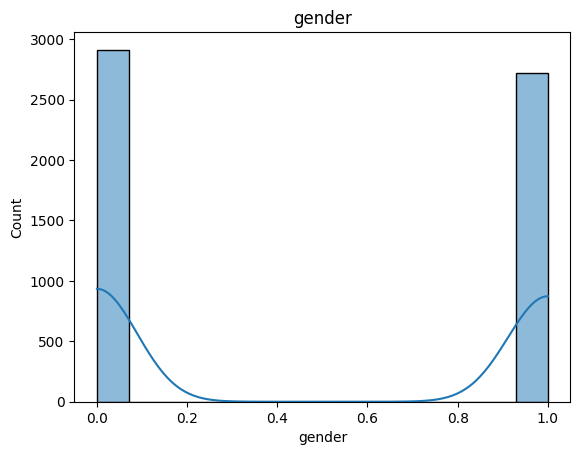

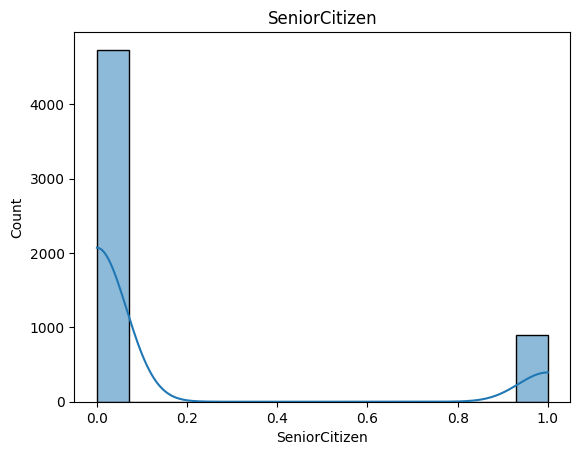

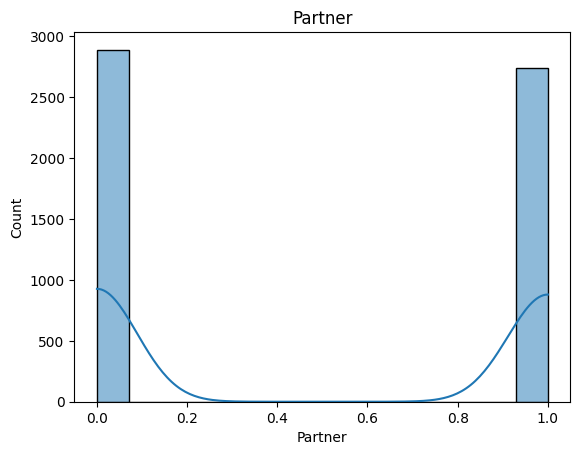

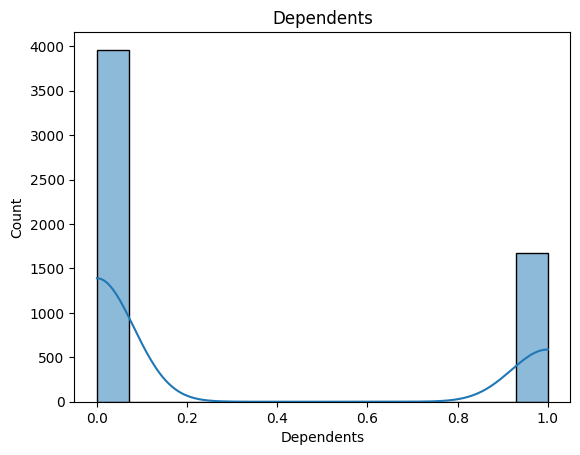

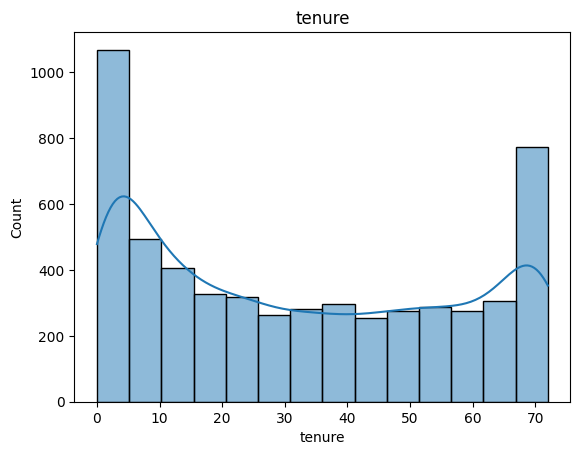

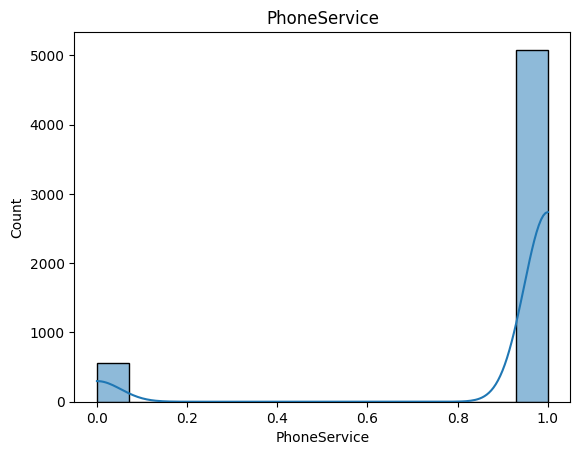

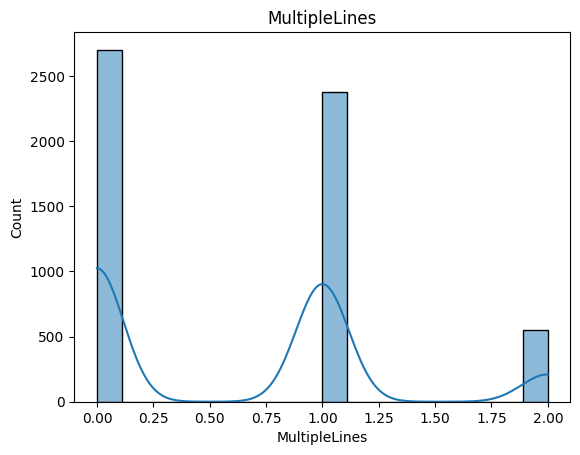

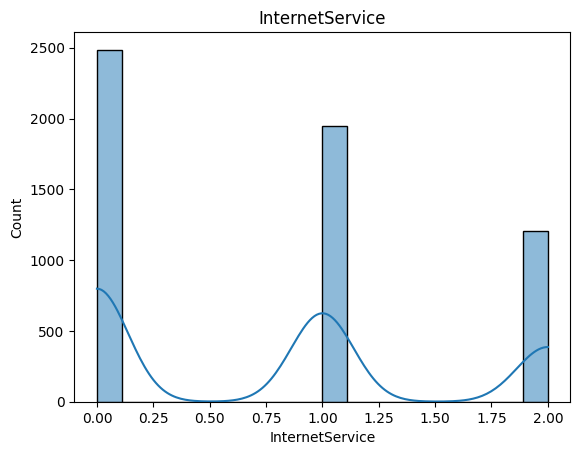

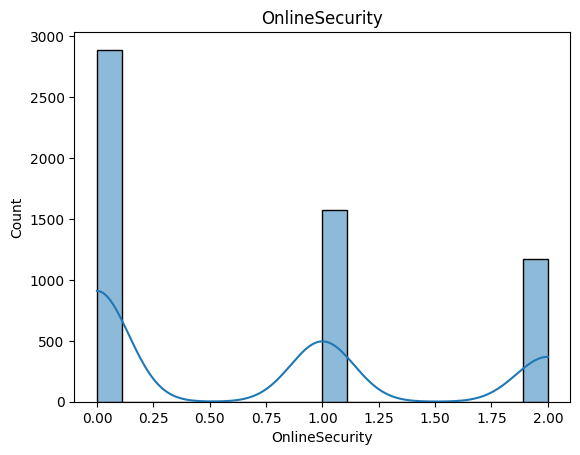

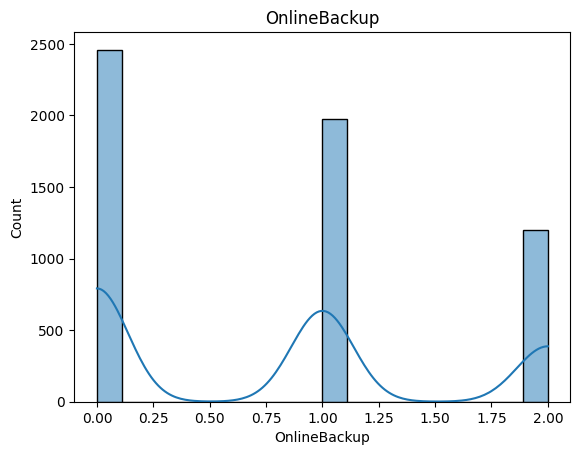

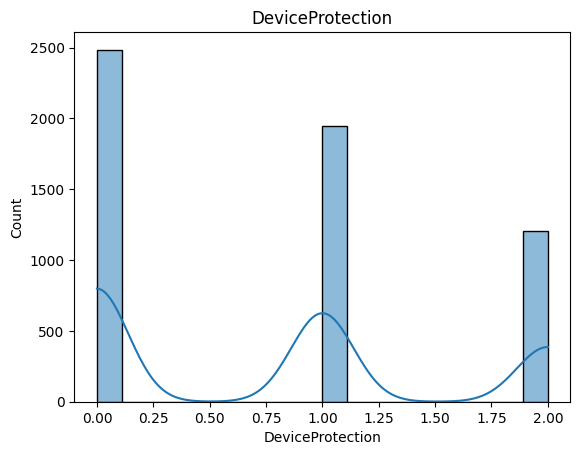

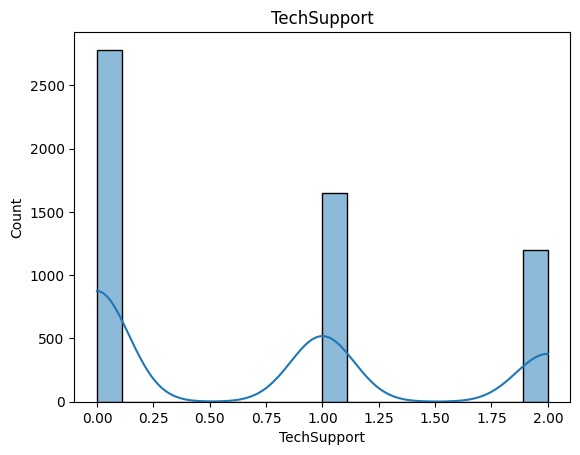

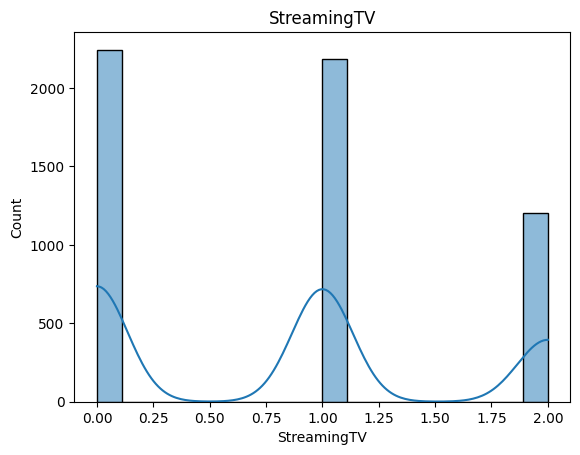

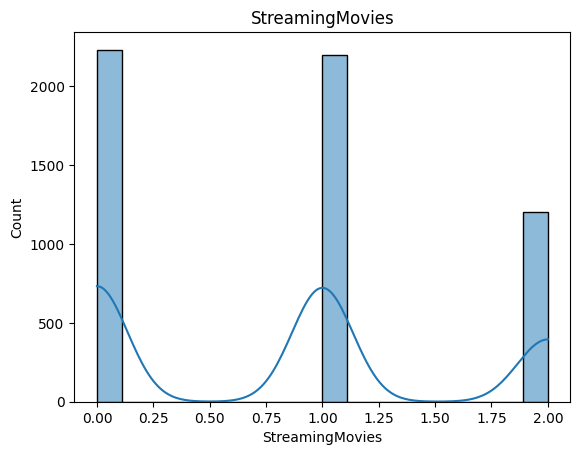

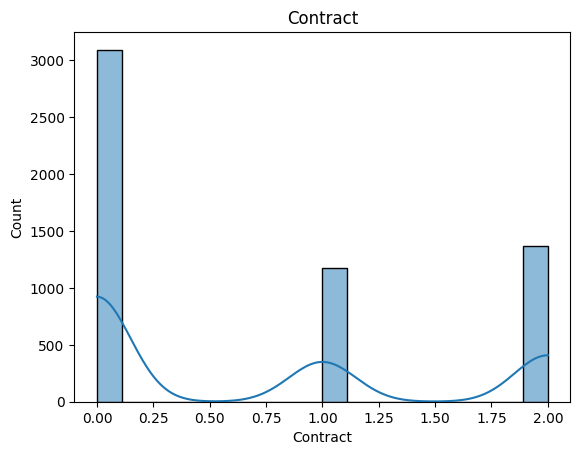

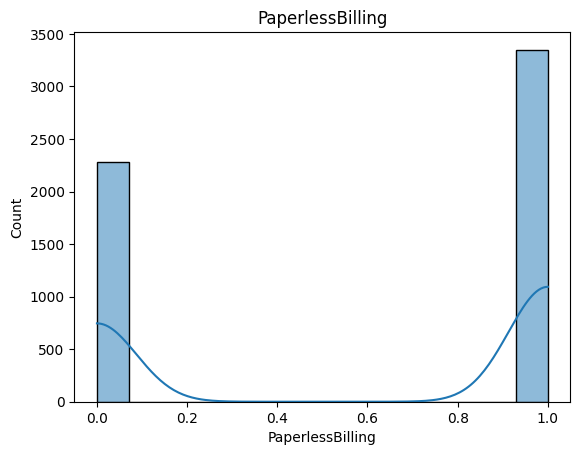

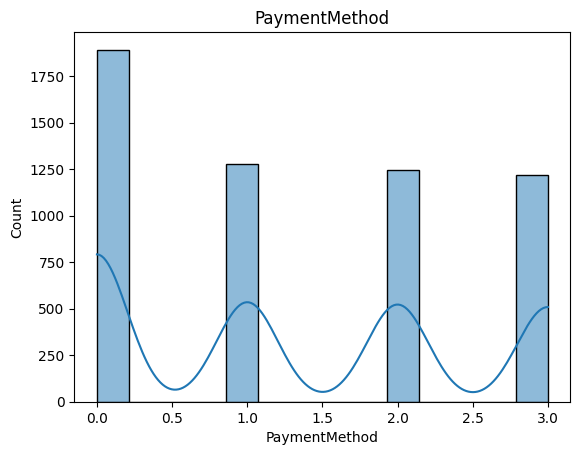

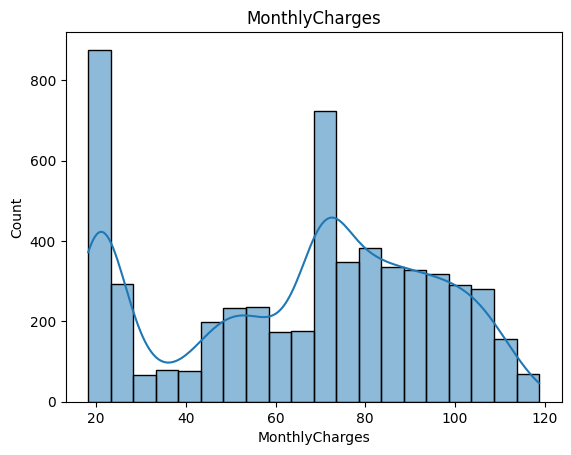

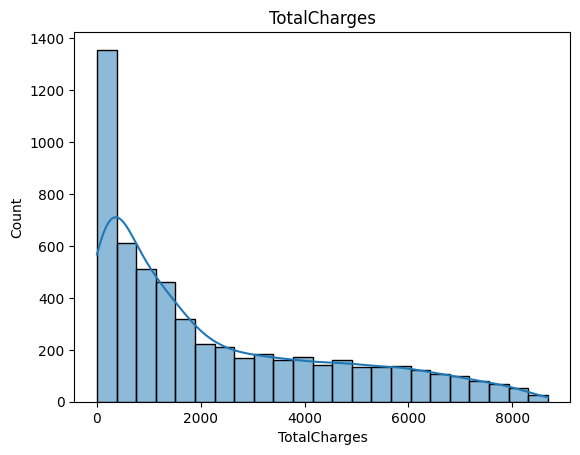

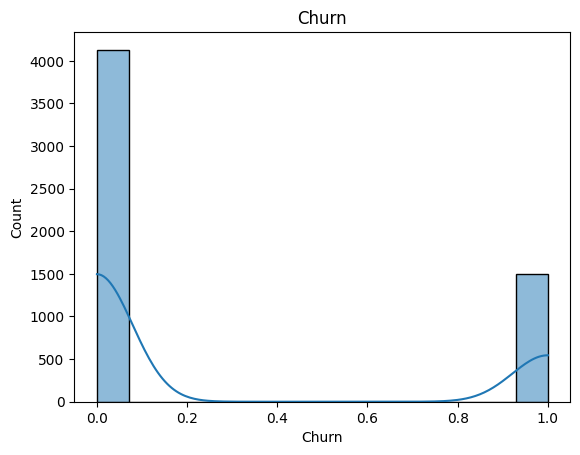

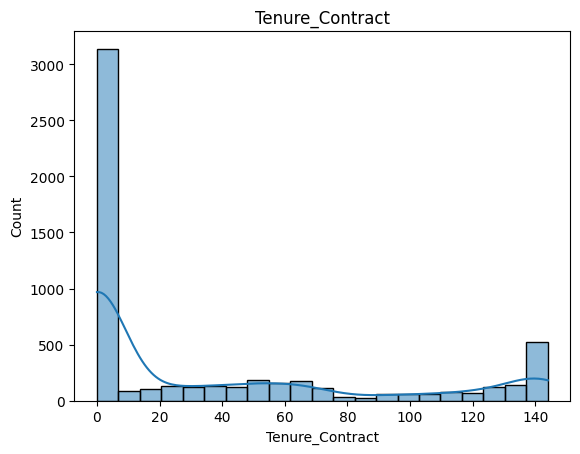

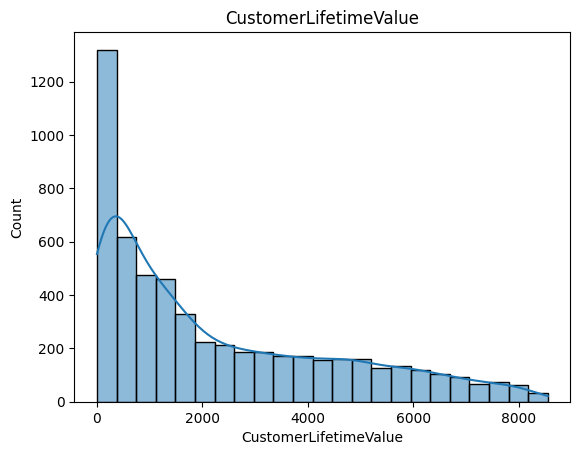

In [28]:
columns = train_df.select_dtypes(include=['number']).columns
for i in columns:
  sns.histplot(train_df[i], kde= True)
  plt.title(i)
  plt.show()

In [29]:
# apply min max scaling for all numerical values
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [30]:
# apply feature selection using selectkbest
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=10)
x_train_new = selector.fit_transform(x_train, y_train)
x_test_new = selector.transform(x_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.805678793256433
[[735  91]
 [128 173]]


In [32]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[]
neighbors = np.arange(3,20)

for i in neighbors:
  knn_model = KNeighborsClassifier(n_neighbors=i)
  knn_model.fit(x_train,y_train)
  y_pred_knn = knn_model.predict(x_test)
  metric_k.append(accuracy_score(y_test,y_pred_knn))

metric_k

[0.7622005323868678,
 0.7790594498669032,
 0.7772848269742679,
 0.7843833185448092,
 0.7781721384205856,
 0.7870452528837621,
 0.7755102040816326,
 0.7879325643300799,
 0.7790594498669032,
 0.7861579414374446,
 0.7834960070984915,
 0.7897071872227152,
 0.7879325643300799,
 0.7914818101153505,
 0.7888198757763976,
 0.7941437444543035,
 0.7888198757763976]

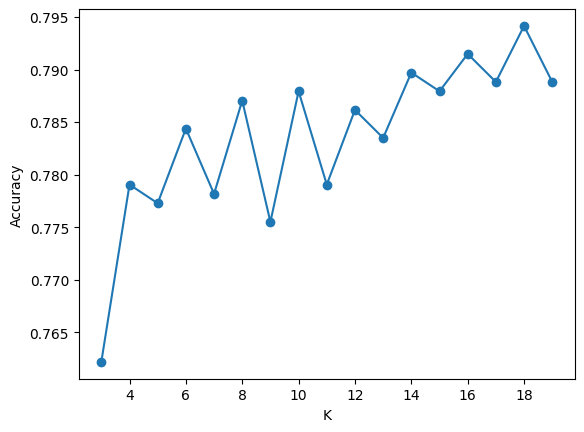

In [33]:
plt.plot(neighbors,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [34]:
knn_classifier = KNeighborsClassifier(n_neighbors=18)
knn_classifier.fit(x_train,y_train)
y_pred_knn = knn_classifier.predict(x_test)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7941437444543035
[[734  92]
 [140 161]]


In [35]:
# to use naive bayes
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.7222715173025732
[[565 261]
 [ 52 249]]


In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
param_grid = {'C':[0.1,1,10,100],'gamma':[1,0.1,0.01,0.001]}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(x_train,y_train)
grid_predictions = grid.predict(x_test)
print('Accuracy Score:')
print(accuracy_score(y_test,grid_predictions))
print('Confusion Matrix:')
print(confusion_matrix(y_test,grid_predictions))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.9s
[CV] END .....................................C=0.1, gamma=1; total time=   0.5s
[CV] END .....................................C=0.1, gamma=1; total time=   0.5s
[CV] END .....................................C=0.1, gamma=1; total time=   0.5s
[CV] END .....................................C=0.1, gamma=1; total time=   0.5s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.5s
[CV] END ..................................C=0.1

In [37]:
# Handle missing values and convert TotalCharges to numeric in test_df
test_df['TotalCharges'] = pd.to_numeric(
    test_df['TotalCharges'], errors='coerce'
)

test_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)
test_df['MonthlyCharges'].fillna(
    train_df['MonthlyCharges'].median(), inplace=True
)
test_df['OnlineSecurity'].fillna(
    test_df['OnlineSecurity'].mode()[0], inplace=True
)
test_df['TotalCharges'].fillna(
    test_df['MonthlyCharges'] * test_df['tenure'], inplace=True
)

# Map categorical features
test_df['gender'] = test_df['gender'].map({'Male': 0, 'Female': 1})
test_df['Partner'] = test_df['Partner'].map({'Yes': 1, 'No': 0})
test_df['Dependents'] = test_df['Dependents'].map({'Yes': 1, 'No': 0})
test_df['PhoneService'] = test_df['PhoneService'].map({'Yes': 1, 'No': 0})
test_df['PaperlessBilling'] = test_df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
test_df['MultipleLines'] = test_df['MultipleLines'].map(
    {'No': 0, 'No phone service': 2, 'Yes': 1}
)
test_df['InternetService'] = test_df['InternetService'].map(
    {'Fiber optic': 0, 'DSL': 1, 'No': 2}
)
test_df['OnlineSecurity'] = test_df['OnlineSecurity'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['OnlineBackup'] = test_df['OnlineBackup'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['DeviceProtection'] = test_df['DeviceProtection'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['TechSupport'] = test_df['TechSupport'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['StreamingTV'] = test_df['StreamingTV'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['StreamingMovies'] = test_df['StreamingMovies'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 2}
)
test_df['Contract'] = test_df['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
)
test_df['PaymentMethod'] = test_df['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3,
})

# Feature Engineering
test_df['Tenure_Contract'] = test_df['tenure'] * test_df['Contract']
test_df['CustomerLifetimeValue'] = test_df['tenure'] * test_df['MonthlyCharges']

/tmp/ipykernel_1396/665191941.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)
/tmp/ipykernel_1396/665191941.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [39]:
# Ensure x_train and x_test are pandas DataFrames with correct column names
feature_names = x.columns.tolist()

x_train = pd.DataFrame(x_train, columns=feature_names)
x_test = pd.DataFrame(x_test, columns=feature_names)

# Now apply StandardScaler
scaler = StandardScaler()
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Tenure_Contract',
    'CustomerLifetimeValue',
]

x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Feature scaling completed successfully!')

Feature scaling completed successfully!


In [40]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  y_prob = model.predict_proba(x_test)[:, 1]

  print(f'=== {name} ===')
  print(classification_report(y_test, y_pred))
  print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n')

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.67      0.58      0.62       301

    accuracy                           0.81      1127
   macro avg       0.76      0.74      0.75      1127
weighted avg       0.80      0.81      0.81      1127

ROC-AUC Score: 0.8492

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       826
           1       0.65      0.52      0.58       301

    accuracy                           0.80      1127
   macro avg       0.74      0.71      0.72      1127
weighted avg       0.79      0.80      0.79      1127

ROC-AUC Score: 0.8365

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       826
           1       0.67      0.57      0.62       301

    accuracy                           0.81      1127
   mac

In [41]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(x_train, y_train)

print('Best Hyperparameters:', grid_search.best_params_)
print(f'Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}')

# Evaluate the tuned model on the test split
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(x_test)
y_prob_tuned = best_rf.predict_proba(x_test)[:, 1]
print('Tuned Random Forest Test ROC-AUC:', roc_auc_score(y_test, y_prob_tuned))

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation ROC-AUC: 0.8456
Tuned Random Forest Test ROC-AUC: 0.852605922148126


In [42]:
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# 2. Set up and run GridSearchCV
gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# 3. Evaluate the tuned model on the unseen test set
best_gb = grid_search.best_estimator_
y_pred_tuned = best_gb.predict(x_test)
y_prob_tuned = best_gb.predict_proba(x_test)[:, 1]

print('\n=== Tuned Gradient Boosting ===')
print(classification_report(y_test, y_pred_tuned))
print(f'Tuned Test ROC-AUC Score: {roc_auc_score(y_test, y_prob_tuned):.4f}')

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.8482

=== Tuned Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       826
           1       0.69      0.54      0.61       301

    accuracy                           0.81      1127
   macro avg       0.77      0.73      0.74      1127
weighted avg       0.80      0.81      0.80      1127

Tuned Test ROC-AUC Score: 0.8522


/tmp/ipykernel_1396/3777620165.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='viridis')


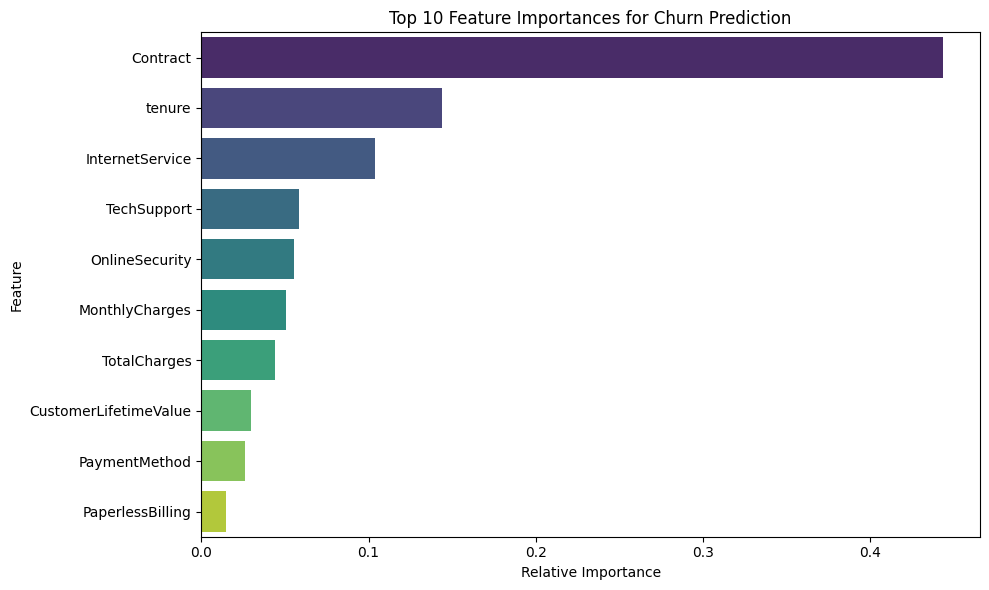

In [43]:
# Extract and plot the top 10 most important features
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = x_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='viridis')
plt.title('Top 10 Feature Importances for Churn Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Conclusion: Key Findings and Business Recommendations

## 1. Model Performance
Our fine-tuned Gradient Boosting Classifier successfully predicts customer churn with an **ROC-AUC score of 0.8522** and an overall **accuracy of 81%**. The model effectively balances precision and recall, allowing the business to reliably identify at-risk customers without overwhelming the retention team with false positives.

## 2. Key Findings & Drivers of Churn
Based on the feature importance analysis and exploratory data analysis, the most significant factors driving customer churn include:
* **Contract Type:** Customers on month-to-month contracts exhibit a significantly higher churn rate compared to those on one-year or two-year contracts.
* **Tenure & Customer Lifetime Value:** Newer customers with lower tenure have a higher propensity to leave. The risk of churn drops as customers spend more time with the company.
* **Monthly Charges:** Pricing plays a crucial role in customer retention, with higher monthly charges often correlating with a higher likelihood of churn.
* **Lack of Premium Services:** Customers without services like Tech Support, Online Security, and Device Protection are more likely to churn, indicating that bundled value-added services increase "stickiness."

## 3. Actionable Business Recommendations
To leverage these insights and reduce customer churn, the following strategic actions are recommended:
* **Incentivize Long-Term Contracts:** Offer targeted discounts, free upgrades, or loyalty perks to encourage month-to-month customers to commit to 1-year or 2-year contracts.
* **Enhance Early Customer Experience (Targeted Onboarding):** Since low-tenure customers are at the highest risk, implement a proactive onboarding and engagement strategy during the first 3 to 6 months to build loyalty and ensure they fully utilize their services.
* **Promote Value-Added Services:** Create attractive bundles that include Tech Support and Online Security at a discounted rate. Customers integrated deeply into the ecosystem are less likely to leave.
* **Evaluate Pricing Strategies:** For customers in high monthly charge brackets who are flagged as high churn risks by the model, consider offering personalized retention discounts or restructuring their plans to better fit their usage needs.